In [23]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

In [29]:


# Load the dataset
df = pd.read_csv("heart 1(in).csv")

# Check the dataset
print("Dataset shape:", df.shape)
display(df.head())

Dataset shape: (918, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [31]:
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Dataset shape: (918, 12)

Column names:
['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']

Data types:
Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

Missing values:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

Duplicate rows:
0


In [33]:
target_column = "HeartDisease"

print("Target column:", target_column)

print("\nTarget distribution:")
print(df[target_column].value_counts())

print("\nTarget proportions:")
print(df[target_column].value_counts(normalize=True))

Target column: HeartDisease

Target distribution:
HeartDisease
1    508
0    410
Name: count, dtype: int64

Target proportions:
HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64


In [35]:
X = df.drop(columns=[target_column])
y = df[target_column]

print("Number of instances:", X.shape[0])
print("Number of input features:", X.shape[1])
print("Target:", target_column)

Number of instances: 918
Number of input features: 11
Target: HeartDisease


In [37]:
# Separate input features and target
X = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

# Identify numerical and categorical columns
numerical_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object"]).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTotal input features:", X.shape[1])

Numerical features:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']

Categorical features:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']

Total input features: 11


In [13]:
print("Missing values in features:")
print(X.isnull().sum())

print("\nMissing values in target:")
print(y.isnull().sum())

Missing values in features:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
dtype: int64

Missing values in target:
0


In [39]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data shape: (734, 11)
Testing data shape: (184, 11)

Training target distribution:
HeartDisease
1    406
0    328
Name: count, dtype: int64

Testing target distribution:
HeartDisease
1    102
0     82
Name: count, dtype: int64


In [41]:
# Encode categorical features using one-hot encoding

X_train_encoded = pd.get_dummies(
    X_train,
    columns=categorical_features,
    drop_first=True
)

X_test_encoded = pd.get_dummies(
    X_test,
    columns=categorical_features,
    drop_first=True
)

# Make sure training and testing have exactly the same columns
X_test_encoded = X_test_encoded.reindex(
    columns=X_train_encoded.columns,
    fill_value=0
)

print("Encoded training shape:", X_train_encoded.shape)
print("Encoded testing shape:", X_test_encoded.shape)

print("\nEncoded feature names:")
print(X_train_encoded.columns.tolist())

Encoded training shape: (734, 15)
Encoded testing shape: (184, 15)

Encoded feature names:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']


In [47]:
# Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_encoded)
X_test_scaled = scaler.transform(X_test_encoded)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (734, 15)
Scaled testing shape: (184, 15)


In [49]:
# Logistic Regression

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [51]:
# Decision Tree

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train_encoded, y_train)

decision_tree_pred = decision_tree_model.predict(X_test_encoded)
decision_tree_prob = decision_tree_model.predict_proba(X_test_encoded)[:, 1]

print("Decision Tree training completed.")

Decision Tree training completed.


In [53]:
# k-Nearest Neighbors

knn_model = KNeighborsClassifier(
    n_neighbors=5
)

knn_model.fit(X_train_scaled, y_train)

knn_pred = knn_model.predict(X_test_scaled)
knn_prob = knn_model.predict_proba(X_test_scaled)[:, 1]

print("kNN training completed.")

kNN training completed.


In [55]:
# Naive Bayes

naive_bayes_model = GaussianNB()

naive_bayes_model.fit(X_train_encoded, y_train)

naive_bayes_pred = naive_bayes_model.predict(X_test_encoded)
naive_bayes_prob = naive_bayes_model.predict_proba(X_test_encoded)[:, 1]

print("Naive Bayes training completed.")

Naive Bayes training completed.


In [57]:
# Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train_encoded, y_train)

random_forest_pred = random_forest_model.predict(X_test_encoded)
random_forest_prob = random_forest_model.predict_proba(X_test_encoded)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [59]:
# Evaluation function

def evaluate_model(model_name, y_true, y_pred, y_prob):
    return {
        "ML Model": model_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "AUC": roc_auc_score(y_true, y_prob),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1": f1_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred)
    }

In [61]:
# Evaluate all five models

results = []

results.append(
    evaluate_model(
        "Logistic Regression",
        y_test,
        logistic_pred,
        logistic_prob
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_test,
        decision_tree_pred,
        decision_tree_prob
    )
)

results.append(
    evaluate_model(
        "kNN",
        y_test,
        knn_pred,
        knn_prob
    )
)

results.append(
    evaluate_model(
        "Naive Bayes",
        y_test,
        naive_bayes_pred,
        naive_bayes_prob
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_test,
        random_forest_pred,
        random_forest_prob
    )
)

results_df = pd.DataFrame(results)

display(results_df.round(4))

,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8859,0.9297,0.8716,0.9314,0.9005,0.7694
1,Decision Tree,0.7826,0.7752,0.7818,0.8431,0.8113,0.5580
2,kNN,0.8859,0.9360,0.8857,0.9118,0.8986,0.7686
3,Naive Bayes,0.9130,0.9451,0.9300,0.9118,0.9208,0.8246
4,Random Forest,0.8750,0.9314,0.8835,0.8922,0.8878,0.7468


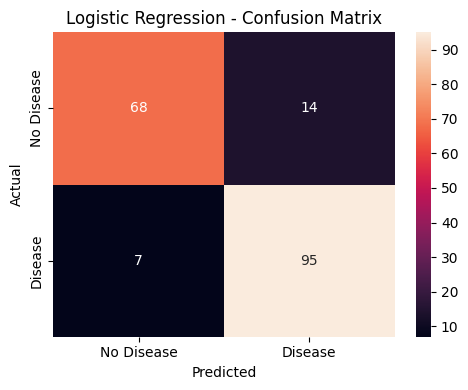

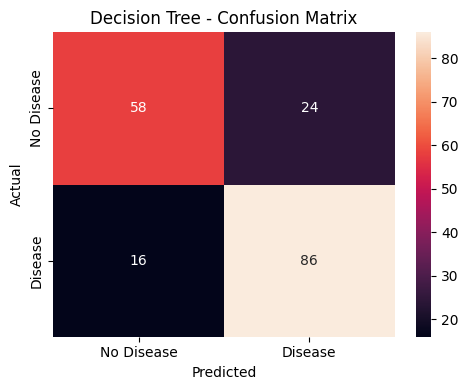

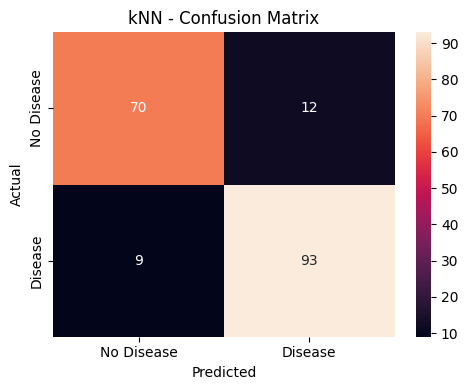

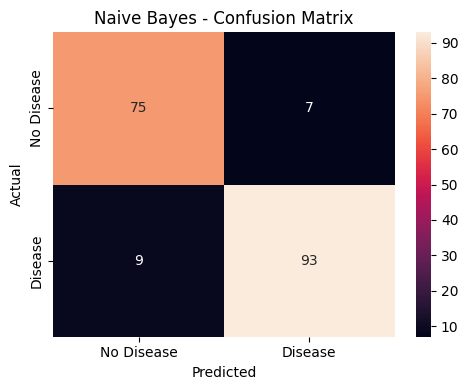

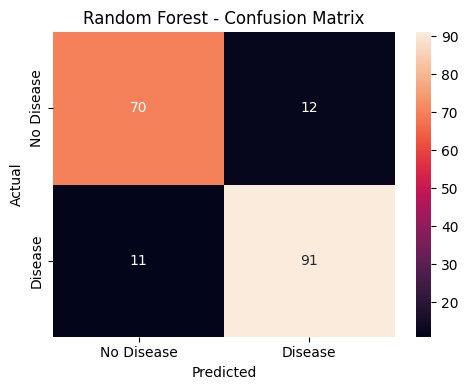

In [63]:
# Confusion matrices for all five models

model_predictions = {
    "Logistic Regression": logistic_pred,
    "Decision Tree": decision_tree_pred,
    "kNN": knn_pred,
    "Naive Bayes": naive_bayes_pred,
    "Random Forest": random_forest_pred
}

for model_name, predictions in model_predictions.items():
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["No Disease", "Disease"],
        yticklabels=["No Disease", "Disease"]
    )

    plt.title(f"{model_name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()

In [64]:
# Classification reports for all five models

for model_name, predictions in model_predictions.items():
    print("=" * 70)
    print(model_name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            predictions,
            target_names=["No Disease", "Disease"]
        )
    )

Logistic Regression
              precision    recall  f1-score   support

  No Disease       0.91      0.83      0.87        82
     Disease       0.87      0.93      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89      0.89       184

Decision Tree
              precision    recall  f1-score   support

  No Disease       0.78      0.71      0.74        82
     Disease       0.78      0.84      0.81       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184

kNN
              precision    recall  f1-score   support

  No Disease       0.89      0.85      0.87        82
     Disease       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.88      0.88       184
weighted avg       0.89      0.89   

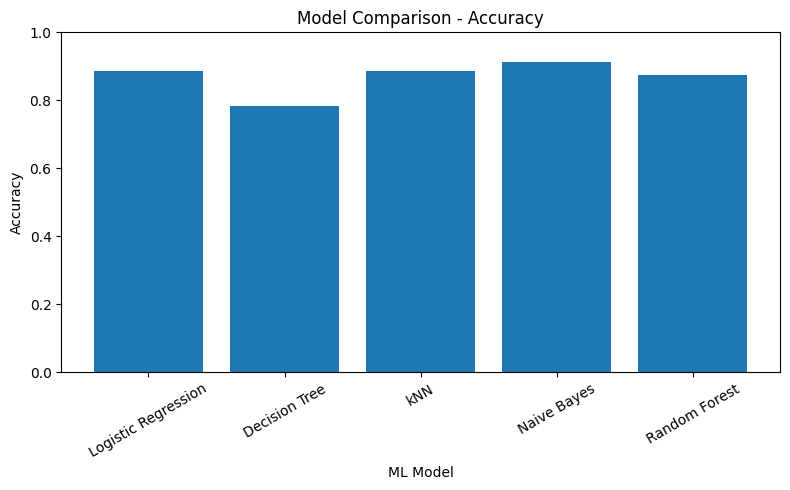

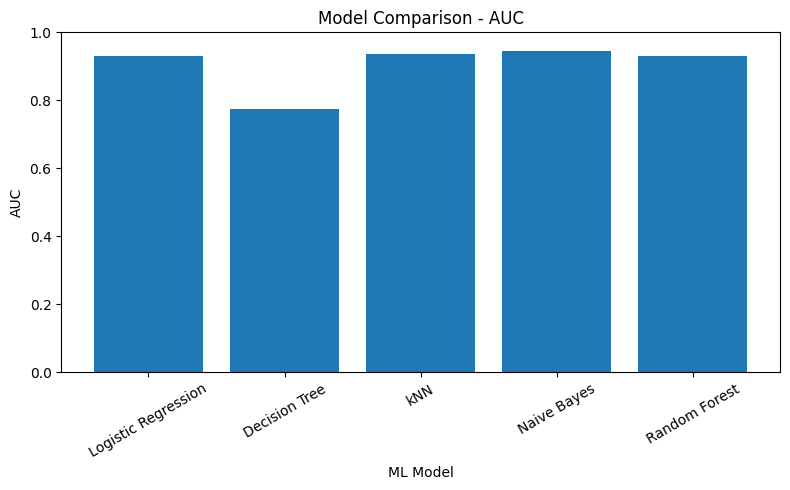

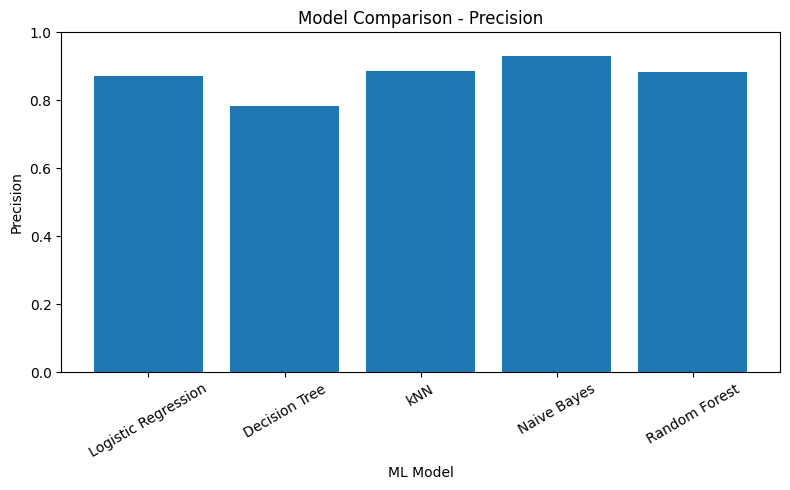

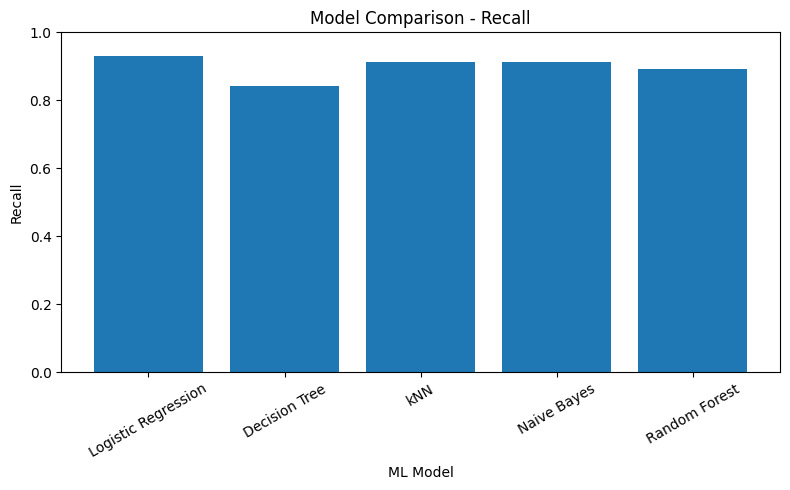

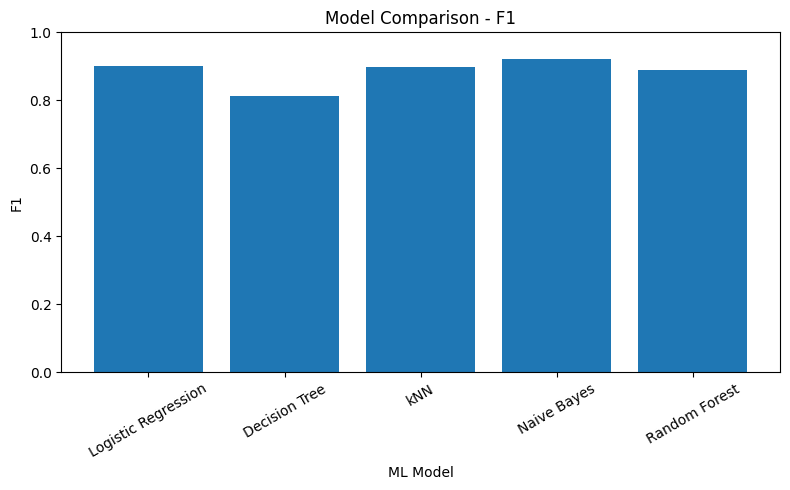

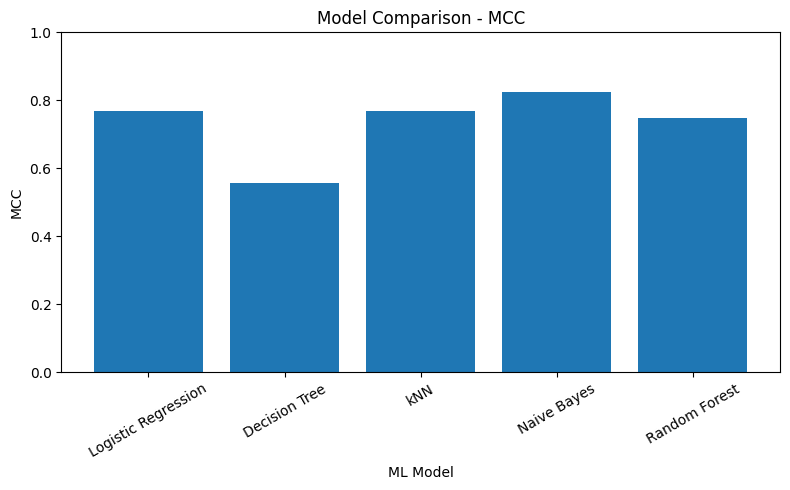

In [67]:
# Model comparison

metrics = ["Accuracy", "AUC", "Precision", "Recall", "F1", "MCC"]

for metric in metrics:
    plt.figure(figsize=(8, 5))

    plt.bar(
        results_df["ML Model"],
        results_df[metric]
    )

    plt.title(f"Model Comparison - {metric}")
    plt.xlabel("ML Model")
    plt.ylabel(metric)
    plt.xticks(rotation=30)
    plt.ylim(0, 1)
    plt.tight_layout()
    plt.show()

In [69]:
# Find the best model based on F1 score

best_model_index = results_df["F1"].idxmax()
best_model = results_df.loc[best_model_index, "ML Model"]
best_f1 = results_df.loc[best_model_index, "F1"]

print("Best model based on F1 score:", best_model)
print("F1 score:", round(best_f1, 4))

Best model based on F1 score: Naive Bayes
F1 score: 0.9208


In [71]:
%pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [72]:
import os
import joblib

# Create model directory
os.makedirs("model", exist_ok=True)

# Save the five trained models
joblib.dump(logistic_model, "model/logistic_regression.pkl")
joblib.dump(decision_tree_model, "model/decision_tree.pkl")
joblib.dump(knn_model, "model/knn.pkl")
joblib.dump(naive_bayes_model, "model/naive_bayes.pkl")
joblib.dump(random_forest_model, "model/random_forest.pkl")

# Save the scaler because Logistic Regression and kNN require scaled input
joblib.dump(scaler, "model/scaler.pkl")

print("All models and scaler saved successfully.")

All models and scaler saved successfully.


In [75]:
print("Files in model folder:")
print(os.listdir("model"))

Files in model folder:
['logistic_regression.pkl', 'decision_tree.pkl', 'knn.pkl', 'naive_bayes.pkl', 'random_forest.pkl', 'scaler.pkl', 'feature_info.json']


In [77]:
# Create test_data.csv

test_data = X_test.copy()
test_data["HeartDisease"] = y_test.values

test_data.to_csv("test_data.csv", index=False)

print("test_data.csv created successfully.")
print("Test data shape:", test_data.shape)

display(test_data.head())

test_data.csv created successfully.
Test data shape: (184, 12)


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
356,46,M,ASY,115,0,0,Normal,113,Y,1.5,Flat,1
763,58,M,NAP,132,224,0,LVH,173,N,3.2,Up,1
817,60,M,ASY,125,258,0,LVH,141,Y,2.8,Flat,1
735,49,M,NAP,120,188,0,Normal,139,N,2.0,Flat,1
892,39,F,NAP,138,220,0,Normal,152,N,0.0,Flat,0


In [79]:
import os

print("test_data.csv exists:", os.path.exists("test_data.csv"))
print("File size:", os.path.getsize("test_data.csv"), "bytes")

test_data.csv exists: True
File size: 7485 bytes


In [81]:
# Save the feature information required by the Streamlit app

import json

feature_info = {
    "target_column": "HeartDisease",
    "categorical_features": categorical_features,
    "numerical_features": numerical_features,
    "encoded_features": X_train_encoded.columns.tolist()
}

with open("model/feature_info.json", "w") as f:
    json.dump(feature_info, f, indent=4)

print("Feature information saved successfully.")
print("Number of encoded features:", len(X_train_encoded.columns))

Feature information saved successfully.
Number of encoded features: 15


In [83]:
with open("model/feature_info.json", "r") as f:
    print(f.read())

{
    "target_column": "HeartDisease",
    "categorical_features": [
        "Sex",
        "ChestPainType",
        "RestingECG",
        "ExerciseAngina",
        "ST_Slope"
    ],
    "numerical_features": [
        "Age",
        "RestingBP",
        "Cholesterol",
        "FastingBS",
        "MaxHR",
        "Oldpeak"
    ],
    "encoded_features": [
        "Age",
        "RestingBP",
        "Cholesterol",
        "FastingBS",
        "MaxHR",
        "Oldpeak",
        "Sex_M",
        "ChestPainType_ATA",
        "ChestPainType_NAP",
        "ChestPainType_TA",
        "RestingECG_Normal",
        "RestingECG_ST",
        "ExerciseAngina_Y",
        "ST_Slope_Flat",
        "ST_Slope_Up"
    ]
}


In [85]:
%%writefile app.py

import streamlit as st
import pandas as pd
import numpy as np
import joblib
import json

from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    confusion_matrix,
    classification_report
)

# --------------------------------------------------
# Page configuration
# --------------------------------------------------

st.set_page_config(
    page_title="Heart Disease ML Classifier",
    page_icon="❤️",
    layout="wide"
)

st.title("Heart Disease Classification")
st.write(
    "Compare five machine learning models for Heart Disease classification."
)

# --------------------------------------------------
# Load preprocessing information
# --------------------------------------------------

with open("model/feature_info.json", "r") as f:
    feature_info = json.load(f)

target_column = feature_info["target_column"]
encoded_features = feature_info["encoded_features"]

# --------------------------------------------------
# Load models
# --------------------------------------------------

models = {
    "Logistic Regression": joblib.load(
        "model/logistic_regression.pkl"
    ),
    "Decision Tree": joblib.load(
        "model/decision_tree.pkl"
    ),
    "kNN": joblib.load(
        "model/knn.pkl"
    ),
    "Naive Bayes": joblib.load(
        "model/naive_bayes.pkl"
    ),
    "Random Forest": joblib.load(
        "model/random_forest.pkl"
    )
}

scaler = joblib.load("model/scaler.pkl")

# --------------------------------------------------
# Sidebar
# --------------------------------------------------

st.sidebar.header("Model Selection")

selected_model = st.sidebar.selectbox(
    "Select a model:",
    list(models.keys())
)

# --------------------------------------------------
# Upload test data
# --------------------------------------------------

st.header("Upload Test Data")

uploaded_file = st.file_uploader(
    "Upload test_data.csv",
    type=["csv"]
)

if uploaded_file is not None:

    test_df = pd.read_csv(uploaded_file)

    st.subheader("Uploaded Data")
    st.dataframe(test_df.head())

    if target_column not in test_df.columns:

        st.error(
            f"The uploaded file must contain the target column "
            f"'{target_column}'."
        )

    else:

        # Separate features and target
        X_uploaded = test_df.drop(
            columns=[target_column]
        )

        y_uploaded = test_df[target_column]

        # Encode categorical columns
        X_encoded = pd.get_dummies(
            X_uploaded,
            drop_first=True
        )

        # Match training feature columns
        X_encoded = X_encoded.reindex(
            columns=encoded_features,
            fill_value=0
        )

        # Select model
        model = models[selected_model]

        # Scale only models that require scaling
        if selected_model in [
            "Logistic Regression",
            "kNN"
        ]:
            X_model = scaler.transform(X_encoded)
        else:
            X_model = X_encoded

        # Predictions
        predictions = model.predict(X_model)
        probabilities = model.predict_proba(X_model)[:, 1]

        # --------------------------------------------------
        # Metrics
        # --------------------------------------------------

        accuracy = accuracy_score(
            y_uploaded,
            predictions
        )

        auc = roc_auc_score(
            y_uploaded,
            probabilities
        )

        precision = precision_score(
            y_uploaded,
            predictions
        )

        recall = recall_score(
            y_uploaded,
            predictions
        )

        f1 = f1_score(
            y_uploaded,
            predictions
        )

        mcc = matthews_corrcoef(
            y_uploaded,
            predictions
        )

        st.header("Evaluation Metrics")

        col1, col2, col3 = st.columns(3)

        col1.metric(
            "Accuracy",
            f"{accuracy:.4f}"
        )

        col2.metric(
            "AUC",
            f"{auc:.4f}"
        )

        col3.metric(
            "Precision",
            f"{precision:.4f}"
        )

        col4, col5, col6 = st.columns(3)

        col4.metric(
            "Recall",
            f"{recall:.4f}"
        )

        col5.metric(
            "F1 Score",
            f"{f1:.4f}"
        )

        col6.metric(
            "MCC",
            f"{mcc:.4f}"
        )

        # --------------------------------------------------
        # Confusion Matrix
        # --------------------------------------------------

        st.header("Confusion Matrix")

        cm = confusion_matrix(
            y_uploaded,
            predictions
        )

        cm_df = pd.DataFrame(
            cm,
            index=["Actual 0", "Actual 1"],
            columns=["Predicted 0", "Predicted 1"]
        )

        st.dataframe(cm_df)

        # --------------------------------------------------
        # Classification Report
        # --------------------------------------------------

        st.header("Classification Report")

        report = classification_report(
            y_uploaded,
            predictions,
            target_names=[
                "No Disease",
                "Disease"
            ],
            output_dict=True
        )

        report_df = pd.DataFrame(report).transpose()

        st.dataframe(
            report_df.round(4)
        )

else:

    st.info(
        "Please upload test_data.csv to evaluate the selected model."
    )

Overwriting app.py


In [87]:
import os

print("app.py exists:", os.path.exists("app.py"))

app.py exists: True


In [89]:
%%writefile requirements.txt

streamlit
pandas
numpy
scikit-learn
joblib

Overwriting requirements.txt


In [3]:
import os

print("requirements.txt exists:", os.path.exists("requirements.txt"))

with open("requirements.txt", "r") as f:
    print(f.read())

requirements.txt exists: True

streamlit
pandas
numpy
scikit-learn
joblib



In [5]:
%%writefile README.md

# Heart Disease Classification

**BITS ID:** 2025AC05939  
**Name:** Kavuri Srilekha  
**Email:** 2025ac05939@wilp.bits-pilani.ac.in  

---

## 1. Problem Statement

The objective of this project is to build and compare multiple machine learning classification models for predicting the presence of heart disease.

The following five machine learning models were implemented and evaluated:

1. Logistic Regression
2. Decision Tree
3. k-Nearest Neighbors (kNN)
4. Naive Bayes
5. Random Forest

The models were evaluated using Accuracy, AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).

---

## 2. Dataset Description

The Heart Disease dataset contains 918 patient records.

The target variable is:

- `HeartDisease`

Target values:

- `0` = No Heart Disease
- `1` = Heart Disease

The input variables include demographic, clinical, and cardiac measurements such as:

- Age
- Sex
- ChestPainType
- RestingBP
- Cholesterol
- FastingBS
- RestingECG
- MaxHR
- ExerciseAngina
- Oldpeak
- ST_Slope

Categorical variables were converted into numerical representations using one-hot encoding.

Numerical features were standardized for models that require feature scaling, particularly Logistic Regression and kNN.

---

## 3. Machine Learning Models

### Logistic Regression

Logistic Regression was used as a linear classification baseline.

### Decision Tree

Decision Tree was used to model non-linear relationships between the input features and target variable.

### k-Nearest Neighbors

kNN was implemented with `k = 5`. Feature scaling was applied because kNN is distance-based.

### Naive Bayes

Gaussian Naive Bayes was used as a probabilistic classification model.

### Random Forest

Random Forest was implemented using 100 decision trees.

---

## 4. Evaluation Metrics

The models were evaluated using:

- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

Confusion matrices and classification reports were also generated.

---

## 5. Model Comparison

The final model comparison table is:

| ML Model | Accuracy | AUC | Precision | Recall | F1 | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | | | | | | |
| Decision Tree | | | | | | |
| kNN | | | | | | |
| Naive Bayes | | | | | | |
| Random Forest | | | | | | |

The values in the table should be updated using the final results obtained from the notebook.

---

## 6. Overall Observation

The five models were compared using multiple evaluation metrics rather than relying only on accuracy.

The model with the strongest overall performance across the evaluation metrics was selected as the preferred model.

---

## 7. Streamlit Application

The Streamlit application provides:

- CSV test-data upload
- Machine learning model selection
- Accuracy display
- AUC display
- Precision display
- Recall display
- F1 Score display
- MCC display
- Confusion matrix
- Classification report

---

## 8. Project Structure

```text
project/
│
├── app.py
├── test_data.csv
├── requirements.txt
├── README.md
│
└── model/
    ├── logistic_regression.pkl
    ├── decision_tree.pkl
    ├── knn.pkl
    ├── naive_bayes.pkl
    ├── random_forest.pkl
    ├── scaler.pkl
    └── feature_info.json

Writing README.md


In [11]:

### 27.2 Verify it

##Run:

##python```
import os

print("README exists:", os.path.exists("README.md"))

with open("README.md", "r") as f:
    print(f.read()[:1000])

README exists: True

# Heart Disease Classification

**BITS ID:** 2025AC05939  
**Name:** Kavuri Srilekha  
**Email:** 2025ac05939@wilp.bits-pilani.ac.in  

---

## 1. Problem Statement

The objective of this project is to build and compare multiple machine learning classification models for predicting the presence of heart disease.

The following five machine learning models were implemented and evaluated:

1. Logistic Regression
2. Decision Tree
3. k-Nearest Neighbors (kNN)
4. Naive Bayes
5. Random Forest

The models were evaluated using Accuracy, AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).

---

## 2. Dataset Description

The Heart Disease dataset contains 918 patient records.

The target variable is:

- `HeartDisease`

Target values:

- `0` = No Heart Disease
- `1` = Heart Disease

The input variables include demographic, clinical, and cardiac measurements such as:

- Age
- Sex
- ChestPainType
- RestingBP
- Cholesterol
- FastingBS
- RestingECG
- Ma

In [13]:
import os

print("Current project folder:")
print(os.getcwd())

print("\nProject files:")
for item in os.listdir("."):
    print(item)

Current project folder:
/home/cloud

Project files:
.mozilla
.bash_logout
.bash_profile
.bashrc
.config
.cache
Desktop
Downloads
Templates
Public
Documents
Music
Pictures
Videos
.local
.ICEauthority
.gnupg
.vnc
.Xauthority
thinclient_drives
.xsession-errors.old
.xsession-errors
.ssh
anaconda3
.conda
.ipython
.vscode
.pki
.jupyter
.ipynb_checkpoints
.keras
.anaconda
.wget-hsts
.continuum
.condarc
anaconda_projects
.python_history
.java
.viminfo
.idea
bike_train.csv
Untitled.ipynb
heart 1(in).csv
2025ac05939_assignment.ipynb
Untitled1.ipynb
model
test_data.csv
app.py
.bash_history
2025ac05939_ML_ASS_2.ipynb
.streamlit
requirements.txt
README.md


In [15]:
print("\nModel folder contents:")

for item in os.listdir("model"):
    print(item)


Model folder contents:
logistic_regression.pkl
decision_tree.pkl
knn.pkl
naive_bayes.pkl
random_forest.pkl
scaler.pkl
feature_info.json


In [17]:
%%writefile .gitignore

# Python
__pycache__/
*.py[cod]

# Jupyter
.ipynb_checkpoints/

# Kaggle credentials
kaggle.json
.kaggle/
access_token

# Environment files
.env

# OS files
.DS_Store

Writing .gitignore


In [19]:
print(open(".gitignore").read())


# Python
__pycache__/
*.py[cod]

# Jupyter
.ipynb_checkpoints/

# Kaggle credentials
kaggle.json
.kaggle/
access_token

# Environment files
.env

# OS files
.DS_Store



In [91]:
display(results_df.round(4))

,ML Model,Accuracy,AUC,Precision,Recall,F1,MCC
0,Logistic Regression,0.8859,0.9297,0.8716,0.9314,0.9005,0.7694
1,Decision Tree,0.7826,0.7752,0.7818,0.8431,0.8113,0.5580
2,kNN,0.8859,0.9360,0.8857,0.9118,0.8986,0.7686
3,Naive Bayes,0.9130,0.9451,0.9300,0.9118,0.9208,0.8246
4,Random Forest,0.8750,0.9314,0.8835,0.8922,0.8878,0.7468


In [93]:
%%writefile README.md

# Heart Disease Classification

**BITS ID:** 2025AC05939  
**Name:** Kavuri Srilekha  
**Email:** 2025ac05939@wilp.bits-pilani.ac.in  

---

## 1. Problem Statement

The objective of this project is to build and compare multiple machine learning classification models for predicting the presence of heart disease.

The following five machine learning models were implemented and evaluated:

1. Logistic Regression
2. Decision Tree
3. k-Nearest Neighbors (kNN)
4. Naive Bayes
5. Random Forest

The models were evaluated using Accuracy, AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).

---

## 2. Dataset Description

The Heart Disease dataset contains 918 patient records.

The target variable is:

- `HeartDisease`

Target values:

- `0` = No Heart Disease
- `1` = Heart Disease

The input variables include:

- Age
- Sex
- ChestPainType
- RestingBP
- Cholesterol
- FastingBS
- RestingECG
- MaxHR
- ExerciseAngina
- Oldpeak
- ST_Slope

Categorical variables were converted into numerical representations using one-hot encoding.

Feature scaling was applied for Logistic Regression and kNN.

---

## 3. Machine Learning Models

### Logistic Regression

Logistic Regression was used as a linear classification model.

### Decision Tree

Decision Tree was used to model non-linear relationships between the input features and target variable.

### k-Nearest Neighbors

kNN was implemented with `k = 5`. Feature scaling was applied because kNN is distance-based.

### Naive Bayes

Gaussian Naive Bayes was used as a probabilistic classification model.

### Random Forest

Random Forest was implemented using 100 decision trees.

---

## 4. Evaluation Metrics

The models were evaluated using:

- Accuracy
- AUC
- Precision
- Recall
- F1 Score
- Matthews Correlation Coefficient (MCC)

Confusion matrices and classification reports were also generated.

---

## 5. Model Comparison

| ML Model | Accuracy | AUC | Precision | Recall | F1 | MCC |
|---|---:|---:|---:|---:|---:|---:|
| Logistic Regression | 0.8859 | 0.9297 | 0.8716 | 0.9314 | 0.9005 | 0.7694 |
| Decision Tree | 0.7826 | 0.7752 | 0.7818 | 0.8431 | 0.8113 | 0.5580 |
| kNN | 0.8859 | 0.9360 | 0.8857 | 0.9118 | 0.8986 | 0.7686 |
| Naive Bayes | 0.9130 | 0.9451 | 0.9300 | 0.9118 | 0.9208 | 0.8246 |
| Random Forest | 0.8750 | 0.9314 | 0.8835 | 0.8922 | 0.8878 | 0.7468 |

---

## 6. Model-wise Observations

### Logistic Regression

Logistic Regression achieved an accuracy of 0.8859 and an AUC of 0.9297. It obtained the highest recall of 0.9314 among the five models, indicating strong identification of positive heart disease cases.

### Decision Tree

Decision Tree produced the lowest overall performance among the five models, with an accuracy of 0.7826 and an AUC of 0.7752. Its MCC of 0.5580 was also the lowest.

### kNN

kNN achieved an accuracy of 0.8859 and an AUC of 0.9360. Its performance was comparable to Logistic Regression, with slightly higher precision but slightly lower recall.

### Naive Bayes

Naive Bayes achieved the best overall performance. It obtained the highest accuracy (0.9130), AUC (0.9451), precision (0.9300), F1 score (0.9208), and MCC (0.8246).

### Random Forest

Random Forest achieved an accuracy of 0.8750 and an AUC of 0.9314. Its performance was stronger than the Decision Tree but lower than Naive Bayes, Logistic Regression, and kNN on most metrics.

---

## 7. Overall Observation

Naive Bayes achieved the strongest overall performance across the evaluation metrics. It obtained the highest Accuracy, AUC, Precision, F1 Score, and MCC.

Logistic Regression achieved the highest Recall at 0.9314.

Based on the overall comparison, **Naive Bayes was selected as the best-performing model** for this dataset.

---

## 8. Streamlit Application

The Streamlit application provides:

- CSV test-data upload
- Machine learning model selection
- Accuracy display
- AUC display
- Precision display
- Recall display
- F1 Score display
- MCC display
- Confusion matrix
- Classification report

---

## 9. Project Structure

```text
project/
│
├── app.py
├── test_data.csv
├── requirements.txt
├── README.md
│
└── model/
    ├── logistic_regression.pkl
    ├── decision_tree.pkl
    ├── knn.pkl
    ├── naive_bayes.pkl
    ├── random_forest.pkl
    ├── scaler.pkl
    └── feature_info.json

Overwriting README.md


In [95]:

##Then verify:python
print("README updated successfully.")

with open("README.md", "r") as f:
    print(f.read()[:2000])

README updated successfully.

# Heart Disease Classification

**BITS ID:** 2025AC05939  
**Name:** Kavuri Srilekha  
**Email:** 2025ac05939@wilp.bits-pilani.ac.in  

---

## 1. Problem Statement

The objective of this project is to build and compare multiple machine learning classification models for predicting the presence of heart disease.

The following five machine learning models were implemented and evaluated:

1. Logistic Regression
2. Decision Tree
3. k-Nearest Neighbors (kNN)
4. Naive Bayes
5. Random Forest

The models were evaluated using Accuracy, AUC, Precision, Recall, F1 Score, and Matthews Correlation Coefficient (MCC).

---

## 2. Dataset Description

The Heart Disease dataset contains 918 patient records.

The target variable is:

- `HeartDisease`

Target values:

- `0` = No Heart Disease
- `1` = Heart Disease

The input variables include:

- Age
- Sex
- ChestPainType
- RestingBP
- Cholesterol
- FastingBS
- RestingECG
- MaxHR
- ExerciseAngina
- Oldpeak
- ST_Slope

Cate

In [97]:
import os

print("Current folder:")
print(os.getcwd())

print("\nMain project files:")

required_files = [
    "app.py",
    "README.md",
    "requirements.txt",
    "test_data.csv",
    ".gitignore"
]

for file in required_files:
    status = "✅" if os.path.exists(file) else "❌"
    print(f"{status} {file}")

Current folder:
/home/cloud

Main project files:
✅ app.py
✅ README.md
✅ requirements.txt
✅ test_data.csv
✅ .gitignore


In [99]:
print("\nModel files:")

required_model_files = [
    "logistic_regression.pkl",
    "decision_tree.pkl",
    "knn.pkl",
    "naive_bayes.pkl",
    "random_forest.pkl",
    "scaler.pkl",
    "feature_info.json"
]

for file in required_model_files:
    path = os.path.join("model", file)
    status = "✅" if os.path.exists(path) else "❌"
    print(f"{status} model/{file}")


Model files:
✅ model/logistic_regression.pkl
✅ model/decision_tree.pkl
✅ model/knn.pkl
✅ model/naive_bayes.pkl
✅ model/random_forest.pkl
✅ model/scaler.pkl
✅ model/feature_info.json


In [101]:
print("\nPotential credential files:")

dangerous_files = [
    "kaggle.json",
    "access_token",
    ".env"
]

for file in dangerous_files:
    if os.path.exists(file):
        print("⚠️ FOUND:", file)
    else:
        print("✅ Not found:", file)


Potential credential files:
✅ Not found: kaggle.json
✅ Not found: access_token
✅ Not found: .env


In [107]:
import os

print("Current working directory:")
print(os.getcwd())

Current working directory:
/home/cloud


In [109]:
print("\nFiles in current directory:")
print(os.listdir("."))


Files in current directory:
['.mozilla', '.bash_logout', '.bash_profile', '.bashrc', '.config', '.cache', 'Desktop', 'Downloads', 'Templates', 'Public', 'Documents', 'Music', 'Pictures', 'Videos', '.local', '.ICEauthority', '.gnupg', '.vnc', '.Xauthority', 'thinclient_drives', '.xsession-errors.old', '.xsession-errors', '.ssh', 'anaconda3', '.conda', '.ipython', '.vscode', '.pki', '.jupyter', '.ipynb_checkpoints', '.keras', '.anaconda', '.wget-hsts', '.continuum', '.condarc', 'anaconda_projects', '.python_history', '.java', '.viminfo', '.idea', 'bike_train.csv', 'Untitled.ipynb', 'heart 1(in).csv', '2025ac05939_assignment.ipynb', 'Untitled1.ipynb', 'model', 'test_data.csv', 'app.py', '.bash_history', '2025ac05939_ML_ASS_2.ipynb', '.streamlit', 'requirements.txt', 'README.md', '.gitignore']


In [ ]:
os.chdir("/home/cloud/20")
print(os.getcwd())
print(os.listdir())